# Actividad 3: Taller EDA — Hábitos de pantalla antes de dormir y deuda de sueño

**Dataset elegido:** *Bedtime Screentime & Sleep Debt* (Kaggle)
**Archivo utilizado:** `bedtime_screentime_sleep_debt.csv`

**¿Por qué este dataset?** Relaciona el uso del celular antes de dormir (tiempo en cama con el
teléfono, brillo de pantalla, filtro de luz azul, app usada) con variables de calidad de sueño
(horas totales de sueño, latencia para dormirse, % de sueño profundo/REM, fatiga al día siguiente y
una categoría de "deuda de sueño"). Es un tema cercano a la vida diaria y permite plantear preguntas
de análisis claras sobre hábitos digitales y descanso.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

df = pd.read_csv('bedtime_screentime_sleep_debt.csv')
df.head(10)


,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt
3,USR-00004,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit
4,USR-00005,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt
5,USR-00006,23,Male,Healthcare / Shift Worker,Intermediate,76,TikTok / Reels,39,0,136,42,50.6,5.87,21.4,17.5,4,5.0,Moderate Debt
6,USR-00007,20,Female,Remote Tech,Night Owl,53,TikTok / Reels,32,0,0,64,36.2,4.43,22.7,19.0,6,6.4,Moderate Debt
7,USR-00008,49,Male,Remote Tech,Morning Lark,113,YouTube,34,1,39,58,60.2,5.94,19.3,19.9,3,4.5,Moderate Debt
8,USR-00009,36,Male,Freelance / Creative,Morning Lark,65,News / Reading,35,1,0,25,28.2,8.00,22.2,18.5,1,1.0,Optimal Recovery
9,USR-00010,40,Female,Student,Night Owl,70,Streaming (Netflix/Hulu),63,1,115,59,53.7,4.70,23.5,16.6,4,7.3,Moderate Debt


## 1. Exploración inicial

### 1.1 Cantidad de filas y columnas, y tipos de dato

In [2]:
print(f"El DataFrame tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
print()
df.dtypes


El DataFrame tiene 8500 filas y 18 columnas.



user_id                         str
age                           int64
gender                          str
occupation_type                 str
chronotype                      str
bedtime_phone_minutes         int64
primary_bedtime_app             str
screen_brightness_pct         int64
blue_light_filter_active      int64
caffeine_post_5pm_mg          int64
physical_activity_min         int64
sleep_latency_min           float64
total_sleep_hours           float64
deep_sleep_pct              float64
rem_sleep_pct               float64
morning_alarm_snoozes         int64
next_day_fatigue_score      float64
sleep_debt_category             str
dtype: object

### 1.2 Valores nulos por columna

In [3]:
df.isnull().sum()


user_id                     0
age                         0
gender                      0
occupation_type             0
chronotype                  0
bedtime_phone_minutes       0
primary_bedtime_app         0
screen_brightness_pct       0
blue_light_filter_active    0
caffeine_post_5pm_mg        0
physical_activity_min       0
sleep_latency_min           0
total_sleep_hours           0
deep_sleep_pct              0
rem_sleep_pct               0
morning_alarm_snoozes       0
next_day_fatigue_score      0
sleep_debt_category         0
dtype: int64

### 1.3 Registros duplicados

In [4]:
print("Filas totalmente duplicadas:", df.duplicated().sum())
print("user_id duplicados:", df['user_id'].duplicated().sum())


Filas totalmente duplicadas: 0
user_id duplicados: 0


### 1.4 Estadísticas descriptivas y categorías

In [5]:
df.describe()


,age,bedtime_phone_minutes,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score
count,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000
mean,34.355647,59.250000,55.153882,0.467765,33.222471,35.701412,40.671471,6.266209,21.735741,19.105859,2.766000,3.794671
std,11.584259,36.931991,19.850550,0.498989,51.935645,20.819390,17.444914,1.446258,3.069377,2.546459,1.695407,2.685153
min,18.000000,1.000000,10.000000,0.000000,0.000000,0.000000,6.000000,3.200000,8.100000,9.600000,0.000000,1.000000
25%,25.000000,31.000000,42.000000,0.000000,0.000000,21.000000,28.200000,5.240000,19.700000,17.400000,2.000000,1.100000
50%,32.000000,51.000000,55.000000,0.000000,0.000000,35.000000,37.600000,6.330000,21.900000,19.100000,3.000000,3.200000
75%,42.000000,79.000000,69.000000,1.000000,55.000000,50.000000,49.700000,7.350000,23.900000,20.800000,4.000000,5.600000
max,65.000000,180.000000,100.000000,1.000000,250.000000,112.000000,123.300000,9.800000,28.000000,27.000000,7.000000,10.000000


In [6]:
for col in ['gender', 'occupation_type', 'chronotype', 'primary_bedtime_app', 'sleep_debt_category']:
    print(f"=== {col} ===")
    print(df[col].value_counts(dropna=False))
    print()


=== gender ===
gender
Female        4347
Male          3905
Non-Binary     248
Name: count, dtype: int64

=== occupation_type ===
occupation_type
Corporate 9-to-5             2838
Remote Tech                  2142
Student                      1622
Healthcare / Shift Worker     997
Freelance / Creative          901
Name: count, dtype: int64

=== chronotype ===
chronotype
Intermediate    3880
Night Owl       2455
Morning Lark    2165
Name: count, dtype: int64

=== primary_bedtime_app ===
primary_bedtime_app
TikTok / Reels              2198
YouTube                     1928
Instagram / Reddit          1630
Streaming (Netflix/Hulu)    1301
Messaging / Chat             847
News / Reading               596
Name: count, dtype: int64

=== sleep_debt_category ===
sleep_debt_category
Moderate Debt        4462
Mild Deficit         2004
Optimal Recovery     1387
Severe Sleep Debt     647
Name: count, dtype: int64



**Diagnóstico:** este dataset no tiene valores nulos ni filas duplicadas, y los rangos de las
variables numéricas (edad 18-65, horas de sueño 3.2-9.8, brillo 10-100%, etc.) son coherentes, sin
valores imposibles. Aun así, a continuación se aplican de forma defensiva las técnicas de limpieza
solicitadas (`dropna`, `fillna`, `replace`) para dejar el flujo preparado ante datos menos limpios, y
se recodifican algunas columnas para que sean más legibles en el análisis.


## 2. Limpieza de datos

### 2.1 `dropna()` y `fillna()` (de forma defensiva)

In [7]:
df_clean = df.copy()

# Defensivo: si existieran filas totalmente vacías, se eliminarían
df_clean = df_clean.dropna(how='all')

# Defensivo: si existieran nulos en columnas numéricas, se rellenarían con la mediana
columnas_numericas = df_clean.select_dtypes(include='number').columns
for c in columnas_numericas:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# Defensivo: nulos en columnas categóricas se rellenarían con 'Unknown'
columnas_categoricas = df_clean.select_dtypes(include='object').columns
for c in columnas_categoricas:
    df_clean[c] = df_clean[c].fillna('Unknown')

print("Nulos después de dropna/fillna:", df_clean.isnull().sum().sum())
df_clean = df_clean.drop_duplicates()
print("Filas después de quitar duplicados:", len(df_clean))


Nulos después de dropna/fillna: 0
Filas después de quitar duplicados: 8500


/tmp/ipykernel_111/1551696880.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df_clean.select_dtypes(include='object').columns


### 2.2 `replace()`: recodificar variables binarias/técnicas a etiquetas legibles

In [8]:
df_clean['blue_light_filter_active'] = df_clean['blue_light_filter_active'].replace({
    0: 'No',
    1: 'Sí'
})

# Se limpia también el formato de texto de las categorías (espacios, capitalización)
for c in ['gender', 'occupation_type', 'chronotype', 'primary_bedtime_app', 'sleep_debt_category']:
    df_clean[c] = df_clean[c].str.strip()

df_clean[['blue_light_filter_active', 'gender', 'occupation_type']].head()


,blue_light_filter_active,gender,occupation_type
0,Sí,Female,Healthcare / Shift Worker
1,Sí,Female,Student
2,No,Female,Healthcare / Shift Worker
3,No,Non-Binary,Remote Tech
4,Sí,Female,Healthcare / Shift Worker


## 3. Filtrado y selección de datos relevantes

Para este análisis, las columnas de identificación (`user_id`) no aportan al análisis estadístico,
por lo que se seleccionan las columnas relevantes para el estudio de hábitos de pantalla y sueño. Además,
se crea un subconjunto filtrado con los usuarios que pasan **más tiempo del promedio con el celular en
la cama**, útil para algunas de las preguntas de análisis.


In [9]:
columnas_relevantes = [
    'age', 'gender', 'occupation_type', 'chronotype',
    'bedtime_phone_minutes', 'primary_bedtime_app', 'screen_brightness_pct',
    'blue_light_filter_active', 'caffeine_post_5pm_mg', 'physical_activity_min',
    'sleep_latency_min', 'total_sleep_hours', 'deep_sleep_pct', 'rem_sleep_pct',
    'morning_alarm_snoozes', 'next_day_fatigue_score', 'sleep_debt_category'
]
df_sel = df_clean[columnas_relevantes]

promedio_minutos_celular = df_sel['bedtime_phone_minutes'].mean()
df_alto_uso = df_sel[df_sel['bedtime_phone_minutes'] > promedio_minutos_celular]

print(f"Promedio de minutos de celular en cama: {promedio_minutos_celular:.1f} min")
print(f"Usuarios con uso por encima del promedio: {len(df_alto_uso)} de {len(df_sel)}")
df_alto_uso.head()


Promedio de minutos de celular en cama: 59.2 min
Usuarios con uso por encima del promedio: 3478 de 8500


,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,Sí,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,58,Female,Student,Intermediate,163,YouTube,76,Sí,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,No,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt
5,23,Male,Healthcare / Shift Worker,Intermediate,76,TikTok / Reels,39,No,136,42,50.6,5.87,21.4,17.5,4,5.0,Moderate Debt
7,49,Male,Remote Tech,Morning Lark,113,YouTube,34,Sí,39,58,60.2,5.94,19.3,19.9,3,4.5,Moderate Debt


## 4. Transformación de columnas y creación de variables nuevas

In [10]:
# Grupo etario
bins_edad = [17, 25, 35, 45, 55, 65]
etiquetas_edad = ['18-25', '26-35', '36-45', '46-55', '56-65']
df_sel['age_group'] = pd.cut(df_sel['age'], bins=bins_edad, labels=etiquetas_edad)

# Horas (en vez de minutos) de celular en cama, más intuitivo
df_sel['bedtime_phone_hours'] = df_sel['bedtime_phone_minutes'] / 60

# Bandera de fatiga alta (umbral: mediana + esperado clínicamente relevante -> se usa 6/10)
df_sel['high_fatigue'] = np.where(df_sel['next_day_fatigue_score'] >= 6, 'Alta fatiga', 'Fatiga baja/moderada')

df_sel[['age', 'age_group', 'bedtime_phone_minutes', 'bedtime_phone_hours',
        'next_day_fatigue_score', 'high_fatigue']].head(8)


,age,age_group,bedtime_phone_minutes,bedtime_phone_hours,next_day_fatigue_score,high_fatigue
0,29,26-35,179,2.983333,10.0,Alta fatiga
1,58,56-65,163,2.716667,10.0,Alta fatiga
2,41,36-45,100,1.666667,10.0,Alta fatiga
3,36,36-45,34,0.566667,1.7,Fatiga baja/moderada
4,23,18-25,27,0.450000,5.3,Fatiga baja/moderada
5,23,18-25,76,1.266667,5.0,Fatiga baja/moderada
6,20,18-25,53,0.883333,6.4,Alta fatiga
7,49,46-55,113,1.883333,4.5,Fatiga baja/moderada


## 5. Agrupaciones y resúmenes (`groupby`)

### 5.1 Horas de sueño promedio por cronotipo

In [11]:
sueno_por_cronotipo = df_sel.groupby('chronotype')['total_sleep_hours'].mean().sort_values()
sueno_por_cronotipo


chronotype
Night Owl       5.011576
Intermediate    6.437936
Morning Lark    7.381141
Name: total_sleep_hours, dtype: float64

### 5.2 Fatiga promedio del día siguiente por tipo de ocupación

In [12]:
fatiga_por_ocupacion = df_sel.groupby('occupation_type')['next_day_fatigue_score'].mean().sort_values()
fatiga_por_ocupacion


occupation_type
Student                      3.513933
Remote Tech                  3.539963
Corporate 9-to-5             3.573221
Freelance / Creative         3.675472
Healthcare / Shift Worker    5.536710
Name: next_day_fatigue_score, dtype: float64

### 5.3 Minutos promedio de celular en cama según la app usada

In [13]:
minutos_por_app = df_sel.groupby('primary_bedtime_app')['bedtime_phone_minutes'].mean().sort_values()
minutos_por_app


primary_bedtime_app
Streaming (Netflix/Hulu)    57.114527
YouTube                     58.289938
Messaging / Chat            59.463991
TikTok / Reels              59.853048
News / Reading              60.092282
Instagram / Reddit          60.857669
Name: bedtime_phone_minutes, dtype: float64

### 5.4 Latencia de sueño promedio según uso de filtro de luz azul

In [14]:
latencia_por_filtro = df_sel.groupby('blue_light_filter_active')['sleep_latency_min'].mean()
latencia_por_filtro


blue_light_filter_active
No    41.597502
Sí    39.617807
Name: sleep_latency_min, dtype: float64

### 5.5 Distribución (%) de categoría de deuda de sueño por ocupación

In [15]:
distribucion_deuda = pd.crosstab(df_sel['occupation_type'], df_sel['sleep_debt_category'], normalize='index') * 100
distribucion_deuda.round(1)


sleep_debt_category,Mild Deficit,Moderate Debt,Optimal Recovery,Severe Sleep Debt
occupation_type,,,,
Corporate 9-to-5,25.4,49.4,18.7,6.4
Freelance / Creative,26.0,50.9,16.2,6.9
Healthcare / Shift Worker,8.7,71.4,1.6,18.3
Remote Tech,24.9,50.9,18.4,5.7
Student,26.4,49.1,18.5,6.0


## 6. Preguntas de análisis, gráficas e interpretación

A continuación se plantean 5 preguntas de análisis, cada una respondida con una gráfica y una
interpretación breve.


### Pregunta 1: ¿Cómo varía el promedio de horas de sueño total según el cronotipo de la persona
(madrugador, nocturno o intermedio)?

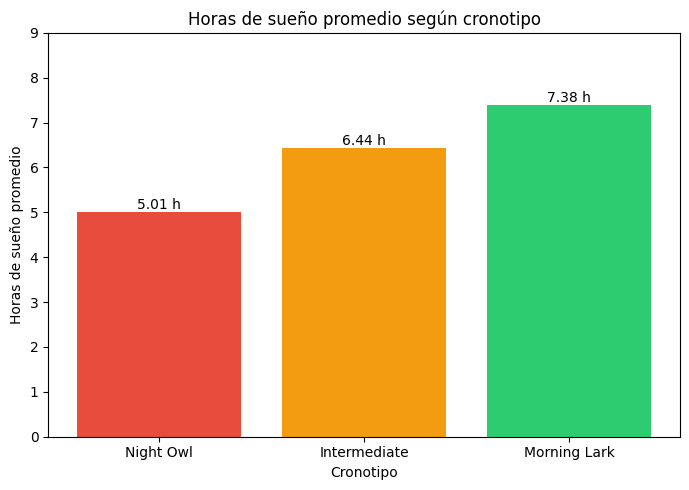

In [16]:
orden = sueno_por_cronotipo.index

fig, ax = plt.subplots(figsize=(7, 5))
barras = ax.bar(orden, sueno_por_cronotipo.values, color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_title('Horas de sueño promedio según cronotipo')
ax.set_xlabel('Cronotipo')
ax.set_ylabel('Horas de sueño promedio')
ax.bar_label(barras, fmt='%.2f h')
ax.set_ylim(0, 9)
plt.tight_layout()
plt.show()


**Interpretación:** los "Night Owl" (nocturnos) duermen en promedio solo ~5.0 horas, frente a ~7.4
horas de los "Morning Lark" (madrugadores) y ~6.4 horas de los "Intermediate". Es una diferencia de
más de 2 horas entre los dos extremos, lo que sugiere que el cronotipo está fuertemente asociado con
la cantidad de sueño que efectivamente se obtiene, probablemente porque los horarios laborales/sociales
no se ajustan bien al ritmo natural de las personas nocturnas.


### Pregunta 2: ¿Existe relación entre el tiempo de uso del celular en la cama y el puntaje de
fatiga del día siguiente?

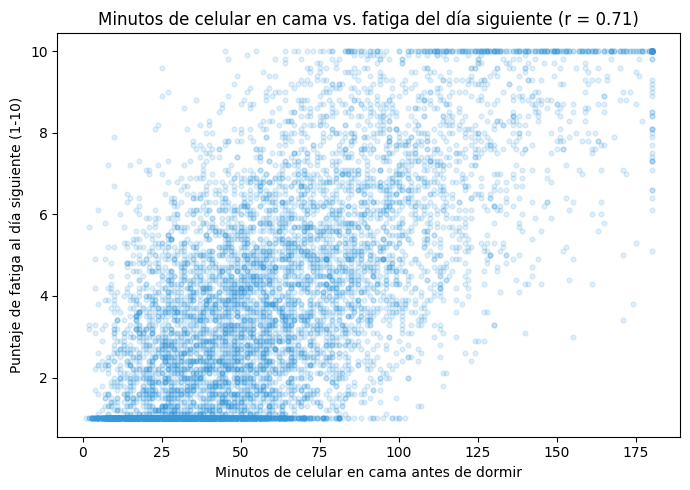

Correlación (Pearson): 0.71


In [17]:
correlacion_fatiga = df_sel['bedtime_phone_minutes'].corr(df_sel['next_day_fatigue_score'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_sel['bedtime_phone_minutes'], df_sel['next_day_fatigue_score'],
           alpha=0.15, s=12, color='#3498db')
ax.set_title(f'Minutos de celular en cama vs. fatiga del día siguiente (r = {correlacion_fatiga:.2f})')
ax.set_xlabel('Minutos de celular en cama antes de dormir')
ax.set_ylabel('Puntaje de fatiga al día siguiente (1-10)')
plt.tight_layout()
plt.show()

print(f"Correlación (Pearson): {correlacion_fatiga:.2f}")


**Interpretación:** la correlación es positiva y fuerte (r ≈ 0.71): a mayor tiempo de celular en
la cama, mayor es el puntaje de fatiga reportado al día siguiente. La nube de puntos muestra una
tendencia ascendente clara, lo que respalda la idea de que el uso prolongado del teléfono antes de
dormir está relacionado con un peor descanso percibido al despertar.


### Pregunta 3: ¿Cómo se distribuye la categoría de deuda de sueño entre los distintos tipos de
ocupación?

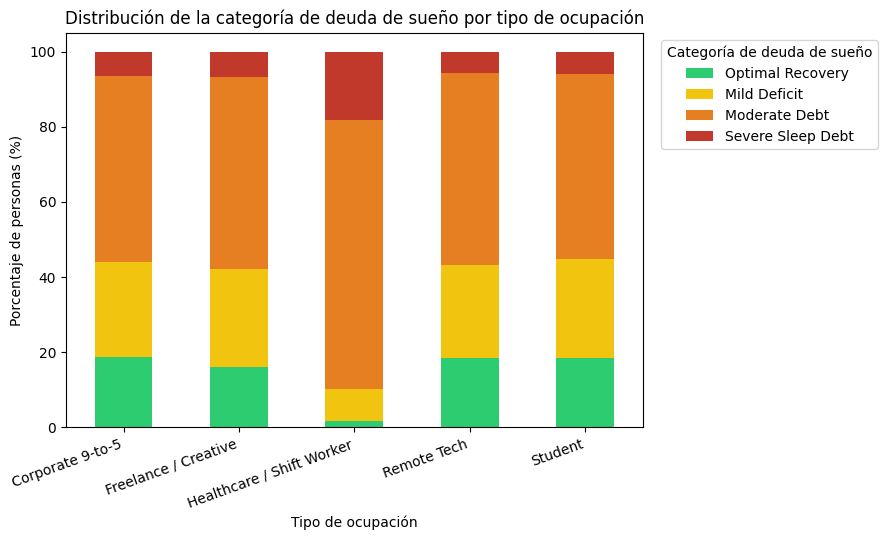

In [18]:
orden_categorias = ['Optimal Recovery', 'Mild Deficit', 'Moderate Debt', 'Severe Sleep Debt']
tabla_plot = distribucion_deuda[orden_categorias]

fig, ax = plt.subplots(figsize=(9, 5.5))
tabla_plot.plot(kind='bar', stacked=True, ax=ax,
                 color=['#2ecc71', '#f1c40f', '#e67e22', '#c0392b'])
ax.set_title('Distribución de la categoría de deuda de sueño por tipo de ocupación')
ax.set_xlabel('Tipo de ocupación')
ax.set_ylabel('Porcentaje de personas (%)')
ax.legend(title='Categoría de deuda de sueño', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


**Interpretación:** el grupo de **"Healthcare / Shift Worker"** se distingue claramente del resto:
un 18.3% cae en "Severe Sleep Debt" (el porcentaje más alto de todas las ocupaciones) y un 71.4% en
"Moderate Debt", mientras que solo un 1.6% logra "Optimal Recovery". En contraste, ocupaciones como
"Student", "Remote Tech" o "Corporate 9-to-5" tienen entre 16% y 19% en "Optimal Recovery". Esto es
consistente con que el trabajo por turnos suele alterar los horarios de sueño de forma más severa que
otras ocupaciones.


### Pregunta 4: ¿El uso del filtro de luz azul se asocia con una menor latencia para quedarse
dormido?

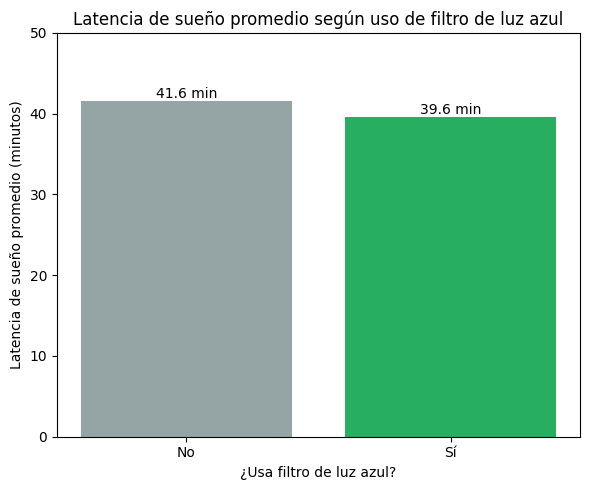

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
barras = ax.bar(latencia_por_filtro.index.astype(str), latencia_por_filtro.values,
                 color=['#95a5a6', '#27ae60'])
ax.set_title('Latencia de sueño promedio según uso de filtro de luz azul')
ax.set_xlabel('¿Usa filtro de luz azul?')
ax.set_ylabel('Latencia de sueño promedio (minutos)')
ax.bar_label(barras, fmt='%.1f min')
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()


**Interpretación:** quienes usan el filtro de luz azul tardan en promedio ~39.6 minutos en
quedarse dormidos, frente a ~41.6 minutos de quienes no lo usan. La diferencia (~2 minutos) es
consistente con la idea de que el filtro ayuda un poco, pero es pequeña en comparación con la
dispersión general de la latencia de sueño, por lo que **por sí solo no parece ser el factor más
determinante** del tiempo que tarda una persona en dormirse.


### Pregunta 5: ¿Qué aplicación usada antes de dormir se asocia con más minutos de celular en
cama?

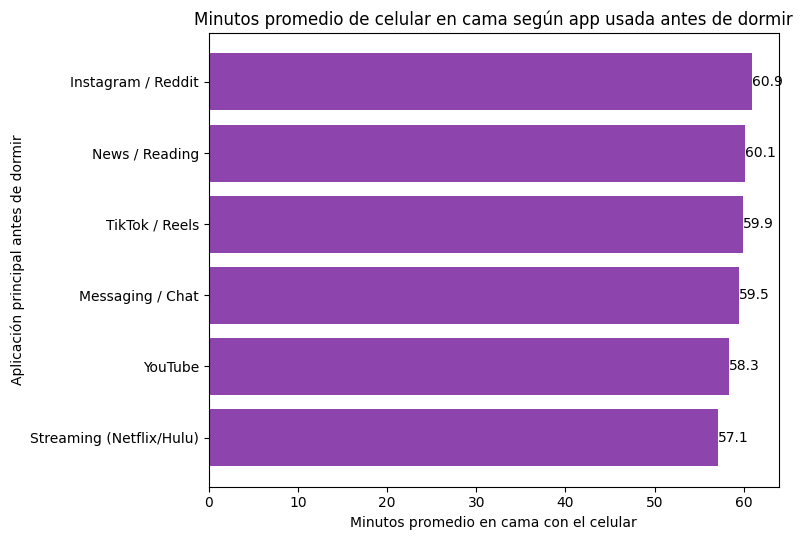

In [20]:
orden_apps = minutos_por_app.sort_values()

fig, ax = plt.subplots(figsize=(8, 5.5))
barras = ax.barh(orden_apps.index, orden_apps.values, color='#8e44ad')
ax.set_title('Minutos promedio de celular en cama según app usada antes de dormir')
ax.set_xlabel('Minutos promedio en cama con el celular')
ax.set_ylabel('Aplicación principal antes de dormir')
ax.bar_label(barras, fmt='%.1f')
plt.tight_layout()
plt.show()


**Interpretación:** las diferencias entre apps son pequeñas (entre ~57 y ~61 minutos en promedio),
con "Instagram / Reddit" y "TikTok / Reels" ligeramente por encima de "Streaming (Netflix/Hulu)" y
"YouTube". Esto sugiere que **el tipo de app específica influye poco** en el tiempo total que la
persona pasa con el celular en la cama; lo que más varía entre usuarios parece ser el hábito general
de quedarse en el celular antes de dormir, más que la app elegida.


## 7. Conclusiones

1. **El cronotipo está fuertemente asociado con la cantidad de sueño obtenida.** Las personas
   "Night Owl" duermen en promedio ~5.0 horas frente a ~7.4 horas de las "Morning Lark", una brecha
   de más de 2 horas. Esto sugiere que los horarios sociales/laborales actuales favorecen a quienes
   tienen un ritmo circadiano más temprano, en perjuicio del descanso de las personas nocturnas.

2. **El tiempo de celular en la cama tiene una relación fuerte y positiva con la fatiga del día
   siguiente (r ≈ 0.71) y una relación negativa con el total de horas dormidas (r ≈ -0.55).** Es
   decir, quienes pasan más tiempo con el celular antes de dormir tienden a dormir menos horas y a
   reportar más fatiga al despertar, lo que respalda la hipótesis de que el uso del celular en la
   cama perjudica la calidad del descanso.

3. **El personal de salud / trabajadores por turnos ("Healthcare / Shift Worker") es el grupo con
   peor perfil de sueño de todo el dataset**: 18.3% en "Severe Sleep Debt" (el más alto de todas las
   ocupaciones) y solo 1.6% en "Optimal Recovery", frente a valores de 16-19% en "Optimal Recovery"
   para el resto de ocupaciones. Esto indica que el tipo de ocupación —y en particular trabajar por
   turnos— es un factor de riesgo importante para la deuda de sueño, más allá de los hábitos de
   pantalla.

4. **Factores como el filtro de luz azul o la app específica usada antes de dormir tienen un efecto
   comparativamente pequeño**: la diferencia en latencia de sueño por usar filtro de luz azul es de
   apenas ~2 minutos, y las diferencias de minutos en cama entre apps son de pocos minutos. Esto
   sugiere que, aunque estas medidas "menores" pueden ayudar marginalmente, no sustituyen a reducir
   el tiempo total de uso del celular en la cama, que es el factor con mayor asociación con la fatiga
   y las horas de sueño.
